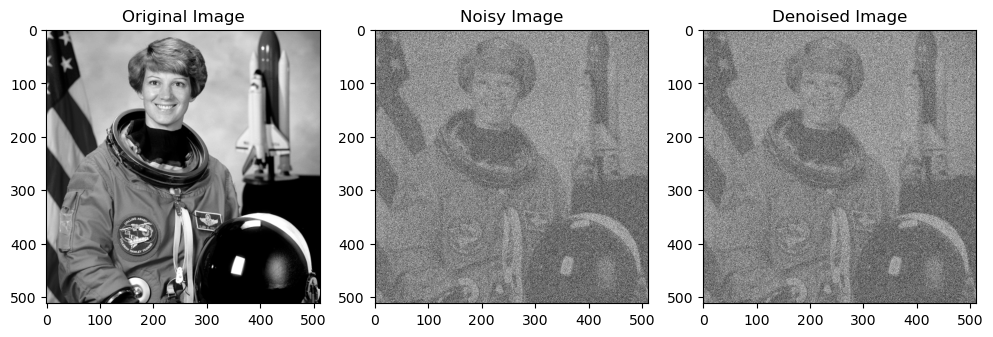

In [2]:
import numpy as np
from sklearn.decomposition import DictionaryLearning
from skimage import color, data

# Load a sample image
image = color.rgb2gray(data.astronaut())

# Add random noise to the image
np.random.seed(0)
noisy_image = image + 0.5 * np.random.normal(size=image.shape)

# Flatten the image to create a 1D signal
noisy_signal = noisy_image.flatten()

# Reshape the signal to a 2D array (n_samples x n_features)
noisy_signal_2d = np.reshape(noisy_signal, (1, -1))

# Apply k-SVD algorithm for denoising
n_components = 200  # Number of dictionary elements
algorithm = 'lars'  # OMP algorithm for sparse coding

ksvd = DictionaryLearning(n_components=n_components, transform_algorithm=algorithm)
denoised_signal_2d = ksvd.fit_transform(noisy_signal_2d).dot(ksvd.components_)

# Reshape the denoised signal back to the original shape
denoised_signal = np.reshape(denoised_signal_2d, image.shape)

# Display the original, noisy, and denoised images
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image')

plt.subplot(1, 3, 3)
plt.imshow(denoised_signal, cmap='gray')
plt.title('Denoised Image')

plt.show()
